# CO2 storage in a layered saline aquifer: verified simulator, hybrid surrogate, verified screening

**The question.** In a sealed, layered saline aquifer, can a cheap surrogate, trained on simulations, predict the peak pressure build-up at the injection well for reservoirs it has never seen -- reliably enough, and with honest enough uncertainty, to screen injection schedules against a pressure limit, with the simulator confirming every recommendation?

**What this notebook is.** The whole study, in order. It runs a simulation, re-computes the key numbers from the saved models, and reads the rest from the finished run. Every output is labelled either

* `[LOADED from the completed study run]` -- read from `results/study/`, produced by `scripts/run_pipeline.py`, `scripts/run_experiments.py` and `scripts/run_model_form.py`, or
* `[COMPUTED NOW in this notebook session]` -- calculated while you run these cells.

**Plan**

1. Purpose, scope and assumptions
2. One simulation, run here
3. Verification, numerical error and model-form error
4. Data roles: development, fresh test, distribution shift
5. Why the published surrogate failed where it did
6. The analytical ROM and the hybrid surrogate; the ablation
7. Results on the untouched test reservoirs and under shift, re-checked here
8. Intervals: what they cover and what they do not
9. Verification-gated schedule screening
10. Conclusions and limitations

**All data are synthetic**, generated by the simulator in this repository. Nothing is calibrated to, or validated against, a real site.

In [1]:
import sys, json, time
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists())
sys.path.insert(0, str(ROOT / 'src'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display
from subsurfaceml.config import load_config

CONFIG = 'study'                 # which completed run this notebook reads
cfg = load_config(ROOT / 'config' / f'{CONFIG}.yaml')
S = json.loads((Path(cfg.paths.metrics) / 'summary.json').read_text())
pd.set_option('display.max_colwidth', 80)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3,
                     'font.size': 9, 'figure.constrained_layout.use': True})


def provenance(kind, what):
    """Label every result: read from a finished run, or computed right here."""
    label = {'loaded': 'LOADED from the completed ' + CONFIG + ' run',
             'computed': 'COMPUTED NOW in this notebook session'}[kind]
    print(f'[{label}]  {what}')

provenance('loaded', f"run of {S['config_file']} started {S['started']}, "
           f"{S['total_wall_seconds']/60:.1f} min wall, python "
           f"{S['environment']['python']}, scikit-learn {S['environment']['scikit_learn']}")
EXP = Path(cfg.paths.results) / 'experiments'

[LOADED from the completed study run]  run of config/study.yaml started Sun Oct  4 06:56:12 2026, 66.0 min wall, python 3.11.15, scikit-learn 1.8.0


## 1. Purpose, scope and assumptions

One rate-controlled injector sits at the centre of a sealed, cylindrical compartment of four horizontal layers. Each layer has its own permeability and porosity; all layers share **one bottom-hole pressure**, solved together with the pressure field. The production simulator leaves out:

| Left out | Consequence | Quantified? |
|---|---|---|
| Gravity / buoyancy | no gravity override under the caprock | yes, with a separate r-z model (section 3) |
| Vertical crossflow between layers | layers communicate only through the well | yes, same r-z model |
| Dissolution and residual trapping | storage security cannot be assessed | no |
| Capillary pressure (`P_c = 0`) | no capillary smearing or entry pressure | no |
| Non-radial geometry, faults, more wells | not a field model | no |

The 9 MPa build-up limit and the 400 m plume-radius limit are **modelling assumptions** that define a screening question; nothing about fracture pressure, caprock integrity or leakage is modelled. Full list: `docs/ASSUMPTIONS.md`.

In [2]:
c = S['config']
print('development reservoirs  :', c['scenarios']['n_realisations'], 'x',
      c['scenarios']['n_schedules_per_realisation'], 'schedules')
print('radial cells / layers   :', c['grid']['n_r'], '/', c['grid']['n_layers'])
print('injection / total [yr]  :', c['schedule']['t_inject_years'], '/',
      c['schedule']['t_total_years'], 'in', c['schedule']['n_periods'], 'rate periods')
print('assumed limits          :', cfg.optim.p_limit_MPa - cfg.solver.p_init_MPa,
      'MPa build-up,', cfg.optim.r_plume_limit_m, 'm plume radius')
print('revised design          :', {k: c['ml'][k] for k in ('feature_set', 'feature_set_plume', 'feature_set_sweep',
      'pressure_model', 'interval_method')})
provenance('loaded', 'configuration of the completed run')

development reservoirs  : 220 x 4 schedules
radial cells / layers   : 60 / 4
injection / total [yr]  : 5.0 / 10.0 in 4 rate periods
assumed limits          : 9.0 MPa build-up, 400.0 m plume radius
revised design          : {'feature_set': 'all', 'feature_set_plume': 'all', 'feature_set_sweep': 'baseline', 'pressure_model': 'hybrid', 'interval_method': 'adaptive_conformal'}
[LOADED from the completed study run]  configuration of the completed run


## 2. One simulation, run here

IMPES (implicit pressure, explicit saturation) on a radial grid with upstream mobilities and harmonic transmissibilities (`3-IMPES.pdf`, `1-Transmissibility.pdf`). The cell takes the first reservoir of the fresh test set, one of its schedules, and simulates it from scratch.

reservoir 10000 : median k = 360 mD, V_DP = 0.82 , thickness = 71 m
injection rates [kg/s]: [0.11 2.   3.05 3.26]


[COMPUTED NOW in this notebook session]  one simulation in 0.4 s (CO2 mass-balance error 5.2e-15)
peak pressure build-up    : 1.33 MPa
plume radius (95% of mass): 176 m


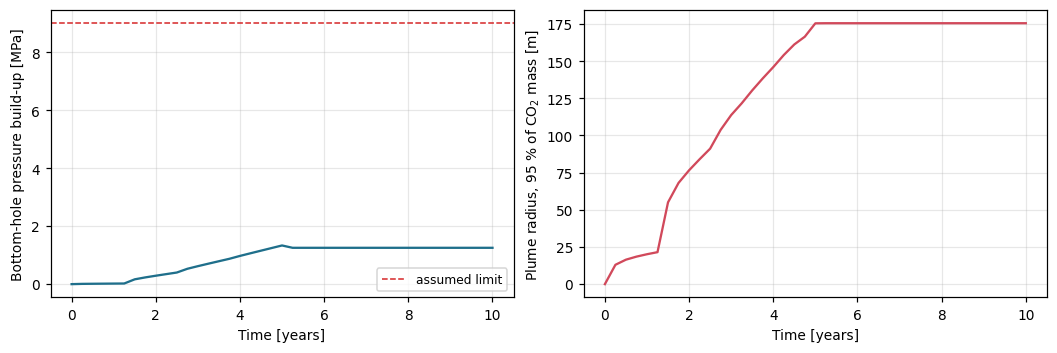

In [3]:
from subsurfaceml.final_eval import eval_realisations
from subsurfaceml.scenarios import sample_schedules, run_scenario
from subsurfaceml.units import MPA, YEAR
ctest, test_reals = eval_realisations(cfg, 'final_test')
r = test_reals[0]                          # generated after the design was fixed
sched = sample_schedules(ctest, r)[0]
print('reservoir', r.realisation_id, ': median k =', round(r.k_median_mD), 'mD, V_DP =',
      round(r.V_DP, 2), ', thickness =', round(r.h_total_m), 'm')
print('injection rates [kg/s]:', np.round(sched['rates_kg_s'], 2))
t0 = time.perf_counter()
out = run_scenario(ctest, r, sched, want_series=True)
row, series = out['row'], out['series']
provenance('computed', f"one simulation in {time.perf_counter()-t0:.1f} s "
           f"(CO2 mass-balance error {row['mass_balance_error']:.1e})")
print('peak pressure build-up    :', round(row['dp_bh_max_Pa']/MPA, 2), 'MPa')
print('plume radius (95% of mass):', round(row['r_plume_m95_m']), 'm')
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.1))
ax[0].plot(series.t_s/YEAR, series.dp_bh_Pa/MPA, color='#1f6f8b')
ax[0].axhline(cfg.optim.p_limit_MPa - cfg.solver.p_init_MPa, color='tab:red', ls='--', lw=1,
              label='assumed limit')
ax[0].set_xlabel('Time [years]'); ax[0].set_ylabel('Bottom-hole pressure build-up [MPa]')
ax[0].legend(fontsize=8)
ax[1].plot(series.t_s/YEAR, series.r_plume_m95_m, color='#d1495b')
ax[1].set_xlabel('Time [years]'); ax[1].set_ylabel('Plume radius, 95 % of CO$_2$ mass [m]')
plt.show()

## 3. Verification, numerical error and model-form error

*Verification* asks whether the equations are solved correctly; it is not validation against measurements (there are none). The pipeline refuses to generate data if any check fails. V12 and V13 check the quantity the surrogates learn -- the two-phase simulator's bottom-hole pressure -- against the pseudo-steady-state solution of a bounded reservoir.

In [4]:
verdict = {k: v for k, v in S['validation_verdict'].items() if k != 'ALL_PASS'}
print(f"{sum(verdict.values())} of {len(verdict)} verification checks pass")
V = json.loads((Path(cfg.paths.metrics)/'validation.json').read_text())
pss = V['V12_V13_pss_well_pressure']
display(pd.DataFrame({k: {'simulated build-up [MPa]': v['sim_dp_bh_MPa'],
                          'PSS analytical [MPa]': v['pss_analytic_dp_MPa'],
                          'relative difference': v['rel_err_sim_vs_pss'],
                          'ROM relative difference': v['rel_err_rom_vs_pss']}
                      for k, v in pss.items()}).T)
provenance('loaded', 'results/study/metrics/validation.json')

21 of 21 verification checks pass


,simulated build-up [MPa],PSS analytical [MPa],relative difference,ROM relative difference
V12_single_layer,25.159489,25.159500,4.349762e-07,2.221004e-15
V13_two_layers,96.870573,96.881842,1.163260e-04,1.190357e-04


[LOADED from the completed study run]  results/study/metrics/validation.json


**Discretisation error of the training data.** A stratified sample of the development cases is re-simulated with the grid, the well block and the time step refined. The question is whether the numerical error of the *targets* is small compared with the surrogate error, and whether it can change a pressure-limit label.

,median_rel,p90_rel,max_rel,max_abs,n
dp_bh_max_MPa,0.000624,0.004840,0.005426,0.166992,41.0
r_plume_m95_m,0.026833,0.034543,0.041003,19.874049,41.0
sweep_efficiency,0.083487,0.150090,0.268390,0.005753,41.0


pressure-limit labels changed by refinement: 0 of 41


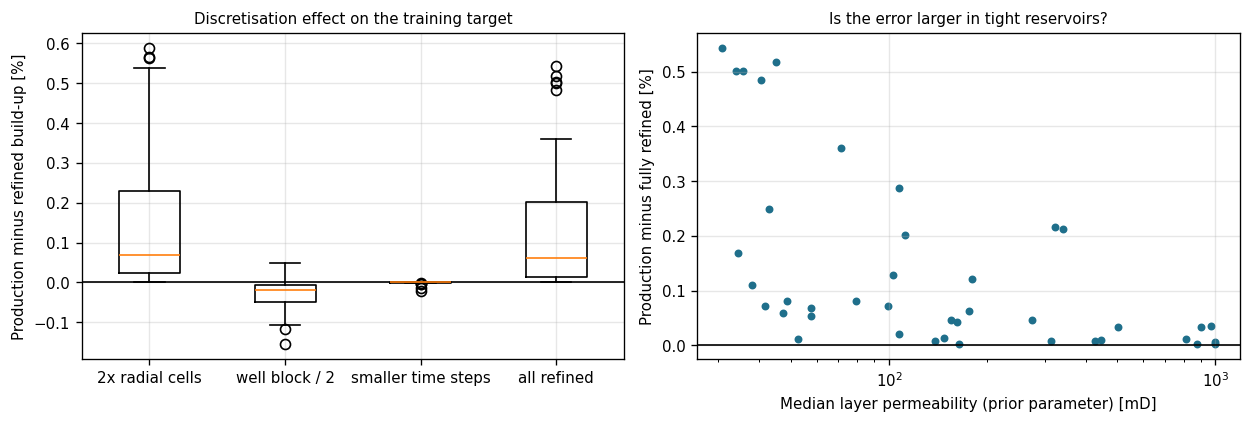

[LOADED from the completed study run]  results/study/metrics/numerics_summary.json


In [5]:
N = S['numerics']
rows = {t: N['targets'][t]['production_minus_fine'] for t in N['targets']}
display(pd.DataFrame(rows).T[['median_rel', 'p90_rel', 'max_rel', 'max_abs', 'n']])
print('pressure-limit labels changed by refinement:', N['pressure_limit_label_flips']['n_flipped'],
      'of', N['pressure_limit_label_flips']['n_compared'])
display(Image(str(Path(cfg.paths.figures)/'17_numerics_dataset_cases.png')))
provenance('loaded', 'results/study/metrics/numerics_summary.json')

**Screen of every case for a transient peak.** A sample cannot reveal a rare failure mode, so every development, test and shift case was screened for a peak build-up that occurs between the stored reporting times -- a transient right after injection starts or the rate rises, whose height depends on the well-block size. Flagged cases were re-simulated with the discretisation refined. The error always over-states the peak.

In [6]:
PS = json.loads((EXP/'peak_screen.json').read_text())
rows = {}
for s_, d_ in PS['sets'].items():
    ch = [c['rel_change_fine'] for c in d_['flagged_cases']]
    rows[s_] = {'cases': d_['n_cases'], 'flagged': d_['n_flagged'],
               'refined peak change, min': min(ch) if ch else None,
               'refined peak change, max': max(ch) if ch else None,
               'limit labels changed': d_['n_limit_label_changes']}
display(pd.DataFrame.from_dict(rows, orient='index').round(3))
for s_ in ('final_test', 'shift'):
    r_ = PS['sets'][s_]['revised_surrogate']
    print(f"{s_}: revised surrogate RMSE {r_['stored_targets']['RMSE']:.3f} MPa with the stored "
          f"targets, {r_['flagged_targets_refined']['RMSE']:.3f} MPa with the flagged cases refined")
provenance('loaded', 'results/study/experiments/peak_screen.json')

,cases,flagged,"refined peak change, min","refined peak change, max",limit labels changed
development,880,4,-0.118,-0.019,0
final_test,400,0,NaN,NaN,0
shift,240,32,-0.139,-0.017,1


final_test: revised surrogate RMSE 0.306 MPa with the stored targets, 0.306 MPa with the flagged cases refined
shift: revised surrogate RMSE 1.952 MPa with the stored targets, 1.944 MPa with the flagged cases refined
[LOADED from the completed study run]  results/study/experiments/peak_screen.json


**Model-form error.** A separate radial-vertical model (`rz.py`) adds buoyancy and vertical crossflow and otherwise keeps everything the same (it reduces to the layered model when both are switched off; `tests/test_rz.py`). The change of each target measures what the layered, no-gravity assumption costs. `k_v/k_h = 0.1` is an assumed value.

,dp_bh_max_MPa (median rel. change),r_plume_m95_m (median rel. change),sweep_efficiency (median rel. change)
gravity_crossflow,-0.042524,0.882840,0.000194
crossflow_only,-0.023796,0.101750,0.001921
gravity_fine,-0.061403,1.012365,-0.005028


pressure-limit labels changed: {'gravity_crossflow': 1, 'crossflow_only': 1, 'gravity_fine': 0}


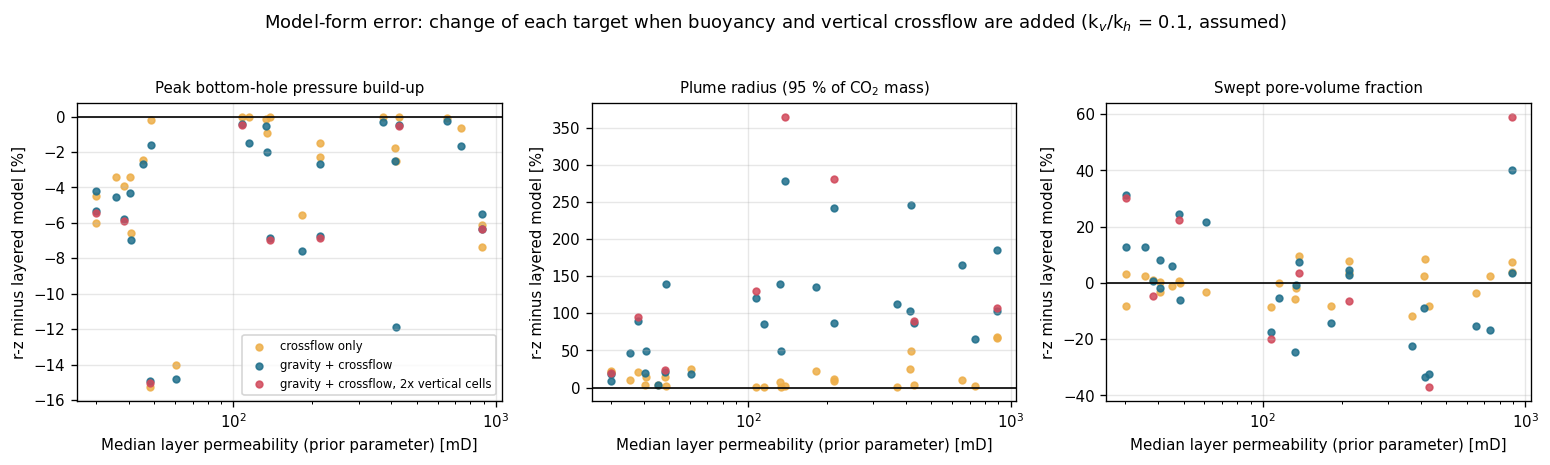

[LOADED from the completed study run]  results/study/experiments/model_form_summary.json


In [7]:
MF = json.loads((EXP/'model_form_summary.json').read_text())
display(pd.DataFrame({v: {t: MF['targets'][v][t]['median_rel_change'] for t in
      ('dp_bh_max_MPa', 'r_plume_m95_m', 'sweep_efficiency')} for v in MF['targets']}).T
        .rename(columns=lambda c: c + ' (median rel. change)'))
print('pressure-limit labels changed:', {v: MF['labels'][v]['n_label_changes'] for v in MF['labels']})
display(Image(str(Path(cfg.paths.figures)/'19_model_form_error.png')))
provenance('loaded', 'results/study/experiments/model_form_summary.json')

## 4. Data roles: development, fresh test, distribution shift

The unit of learning is the **reservoir realisation**: its schedules share one reservoir, so every split and every cross-validation fold is by whole reservoir. The published run's 55 test reservoirs were inspected while this revision was developed, so they now train; the test reservoirs below were generated after every modelling choice had been fixed (`docs/EVALUATION_PROTOCOL.md`).

In [8]:
print('reservoirs per role :', S['ml']['leakage']['reservoirs'])
print('rows per role       :', S['ml']['leakage']['rows'])
print('overlaps            :', S['ml']['leakage']['overlaps'], '(all must be 0)')
print('disjoint sets       :', S['evaluation_sets']['disjoint'])
for k, v in S['evaluation_sets']['provenance'].items():
    print(f"{k:10s}: seed {v['seed']}, {v['n_realisations']} reservoirs, median k in {v['k_median_mD_range']} mD,"
          f" {v['n_success']} ok / {v['n_failed']} failed")
provenance('loaded', 'split and evaluation-set records of the completed run')

reservoirs per role : {'train': 179, 'calib': 41, 'test': 100, 'shift': 60}
rows per role       : {'train': 716, 'calib': 164, 'test': 400, 'shift': 240}
overlaps            : {'train_calib': 0, 'train_test': 0, 'train_shift': 0, 'calib_test': 0, 'calib_shift': 0, 'test_shift': 0} (all must be 0)
disjoint sets       : {'overlapping_ids': 0, 'overlapping_descriptions': 0}
final_test: seed 20261104, 100 reservoirs, median k in [30.0, 1000.0] mD, 400 ok / 0 failed
shift     : seed 20261105, 60 reservoirs, median k in [10.0, 30.0] mD, 240 ok / 0 failed
[LOADED from the completed study run]  split and evaluation-set records of the completed run


## 5. Why the published surrogate failed where it did

The published surrogate described a reservoir by the parameters of its sampling prior -- median permeability and target Dykstra-Parsons coefficient. The simulator uses four *realised* layers drawn from that prior. With four draws, the realised layers can be far tighter or more permeable than the parameters imply. The cell computes, for the published run's worst pressure cases, the realised arithmetic-mean permeability against what the prior parameters lead one to expect.

In [9]:
from subsurfaceml.evaluation import prior_mean_arith_k
dev = pd.read_csv(Path(cfg.paths.data)/'scenarios_features.csv')
worst = ['R0172_S+00', 'R0039_S+03', 'R0036_S+02', 'R0150_S+03']
w = dev.set_index('scenario_id').loc[worst]
tab = pd.DataFrame({'simulated build-up [MPa]': w.dp_bh_max_MPa,
                    'median k (prior) [mD]': w.k_median_mD,
                    'V_DP (prior)': w.V_DP, 'V_DP realised': w.V_DP_layers,
                    'expected mean k [mD]': prior_mean_arith_k(w.k_median_mD, w.V_DP),
                    'realised mean k [mD]': w.k_arith_mean_m2 / 9.869233e-16}).round(2)
tab['realised / expected'] = (tab['realised mean k [mD]'] / tab['expected mean k [mD]']).round(2)
display(tab)
provenance('computed', 'from the development data set; the published predictions for these '
           'cases were 17.6, 18.8, 7.9 and 11.5 MPa (results/published_2026-09-20/)')

,simulated build-up [MPa],median k (prior) [mD],V_DP (prior),V_DP realised,expected mean k [mD],realised mean k [mD],realised / expected
scenario_id,,,,,,,
R0172_S+00,32.44,45.21,0.65,0.32,78.71,23.65,0.30
R0039_S+03,13.14,47.35,0.81,0.88,194.43,2371.03,12.19
R0036_S+02,11.71,40.50,0.71,0.34,86.39,26.42,0.31
R0150_S+03,14.74,30.80,0.28,0.21,32.53,31.07,0.96


[COMPUTED NOW in this notebook session]  from the development data set; the published predictions for these cases were 17.6, 18.8, 7.9 and 11.5 MPa (results/published_2026-09-20/)


## 6. The analytical ROM and the hybrid surrogate; the ablation

`rom.py` treats each realised layer as a sealed tank in pseudo-steady state, all connected to one bottom-hole pressure with the simulator's injector-only rule. It uses no simulator output. The hybrid surrogate learns only the correction factor the ROM needs: `ln(dp) = ln(dp_ROM) + g(x)`. The ablation compares variants with nested, reservoir-grouped cross-validation on the development reservoirs only, with identical folds and search budgets.

[COMPUTED NOW in this notebook session]  ROM alone on all 880 development cases: RMSE 0.559 MPa, MAE 0.258 MPa, worst under-prediction 4.74 MPa


,RMSE,MAE,p95_abs_error,worst_underprediction,max_abs_error,"dRMSE vs V0, 95% CI"
V0_published_features,1.138,0.471,1.929,15.847,15.847,
V1_plus_realised_rock,0.844,0.301,1.166,12.829,12.829,"[-0.463, -0.112]"
V2_plus_rom_feature,0.458,0.176,0.750,8.354,8.354,"[-0.85, -0.504]"
V3_hybrid_rom_residual,0.266,0.103,0.420,4.639,4.639,"[-1.09, -0.656]"
V4_rom_only,0.559,0.258,1.178,4.745,4.745,"[-0.825, -0.327]"
V5_published_features_3x_search,1.169,0.475,1.852,15.847,15.847,"[-0.025, 0.127]"


decisions (pre-declared rules): {'pressure_variant': 'V3_hybrid_rom_residual', 'ml.feature_set': 'all', 'ml.pressure_model': 'hybrid', 'ml.feature_set_plume': 'all', 'other_targets_rmse': {'r_plume_m95_m': {'V0_published_features': 9.57485602795739, 'V2_plus_rock_and_rom_features': 6.510649696040826}, 'sweep_efficiency': {'V0_published_features': 0.0010886009247356569, 'V2_plus_rock_and_rom_features': 0.0011160717889445067}}, 'ml.feature_set_sweep': 'baseline', 'ml.interval_method': 'adaptive_conformal', 'interval_rule': 'smallest mean relative width with mean whole-reservoir coverage >= 0.88'}


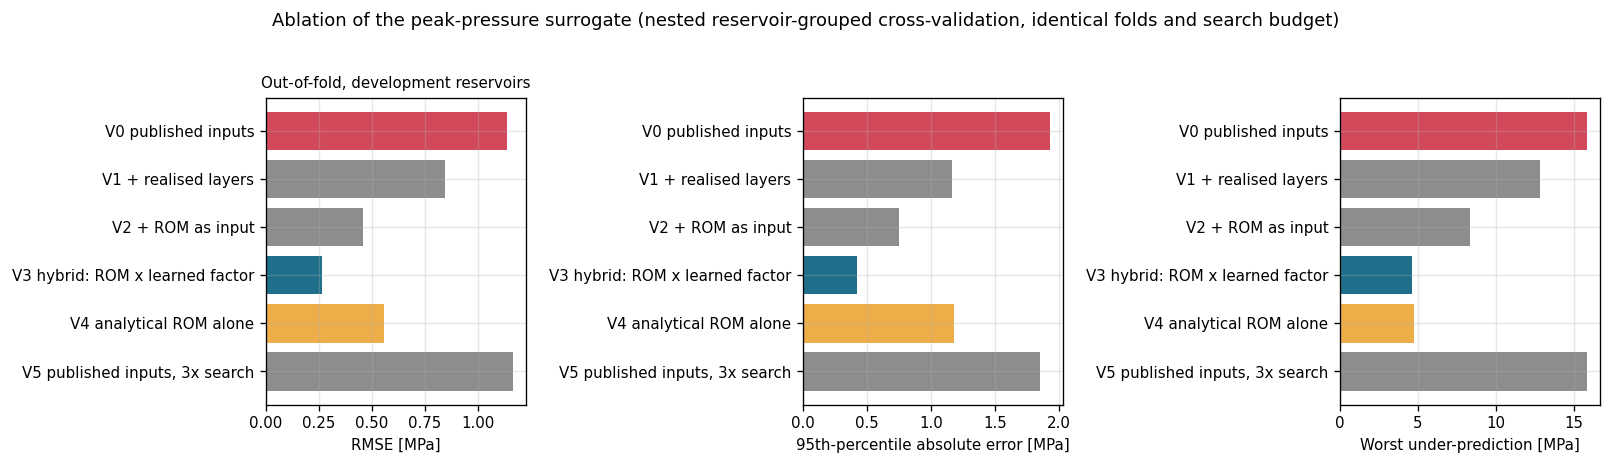

[LOADED from the completed study run]  results/study/experiments/ablation_summary.json


In [10]:
from subsurfaceml.evaluation import point_metrics
rom_dp = 10 ** dev['log10_rom_dp_MPa']
m = point_metrics(dev['dp_bh_max_MPa'], rom_dp)
provenance('computed', f"ROM alone on all {m['n']} development cases: RMSE {m['RMSE']:.3f} MPa, "
           f"MAE {m['MAE']:.3f} MPa, worst under-prediction {m['worst_underprediction']:.2f} MPa")
A = json.loads((EXP/'ablation_summary.json').read_text())
met = A['targets']['dp_bh_max_MPa']['metrics']
keys = ['RMSE', 'MAE', 'p95_abs_error', 'worst_underprediction', 'max_abs_error']
tab = pd.DataFrame({v: {k: met[v][k] for k in keys} for v in met}).T.round(3)
tab['dRMSE vs V0, 95% CI'] = [str([round(x, 3) for x in met[v]['vs_V0_published_features']['RMSE']['ci95']])
                              if 'vs_V0_published_features' in met[v] else '' for v in met]
display(tab)
print('decisions (pre-declared rules):', A['decisions'])
display(Image(str(Path(cfg.paths.figures)/'16_ablation_pressure.png')))
provenance('loaded', 'results/study/experiments/ablation_summary.json')

## 7. Results on the untouched test reservoirs and under shift, re-checked here

Three things are compared on the same reservoirs: the revised design, the published approach retrained on the same development reservoirs, and the published models as released. The second cell does not trust the table: it loads the saved revised models, re-predicts the fresh test reservoirs and recomputes the metrics.

In [11]:
rows = []
for t, res in S['ml']['targets'].items():
    for d, dd in res['designs'].items():
        for s_ in ('test', 'shift'):
            p = dd['evaluation'][s_]['point']
            rows.append({'target': t, 'design': d, 'set': s_, 'model': dd['selected_model'],
                         'RMSE': p['RMSE'], 'MAE': p['MAE'], 'R2': p['R2'],
                         'P95 |error|': p['p95_abs_error'],
                         'worst under': p['worst_underprediction']})
display(pd.DataFrame(rows).set_index(['target', 'set', 'design']).round(4))
b = S['ml']['targets']['dp_bh_max_MPa']['bootstrap']
for k, v in b.items():
    print(k, ': dRMSE', round(v['RMSE']['difference_b_minus_a'], 4), 'MPa, 95% CI',
          [round(x, 4) for x in v['RMSE']['ci95']])
provenance('loaded', 'final evaluation of the completed study run')

model     RMSE  \
target           set   design                                              
dp_bh_max_MPa    test  revised                              svr   0.3057   
                 shift revised                              svr   1.9519   
                 test  published_approach                   svr   0.7010   
                 shift published_approach                   svr   3.8137   
                 test  published_models_as_released         svr   0.6702   
                 shift published_models_as_released         svr   3.7606   
r_plume_m95_m    test  revised                              svr   6.3573   
                 shift revised                              svr   8.4654   
                 test  published_approach                   svr  11.3032   
                 shift published_approach                   svr  12.5292   
                 test  published_models_as_released  elasticnet  13.8308   
                 shift published_models_as_released  elasticnet  13.7716   
sweep_efficiency test  revised                              svr   0.0009   
                 shift revised                              svr   0.0006   
                 test  published_approach                   svr   0.0009   
                 shift published_approach                   svr   0.0006   
                 test  published_models_as_released         svr   0.0010   
                 shift published_models_as_released         svr   0.0010   

                                                        MAE      R2  \
target           set   design                                         
dp_bh_max_MPa    test  revised                       0.1250  0.9962   
                 shift revised                       0.6053  0.9066   
                 test  published_approach            0.2976  0.9802   
                 shift published_approach            1.5268  0.6433   
                 test  published_models_as_released  0.3031  0.9819   
                 shift published_models_as_released  1.5192  0.6531   
r_plume_m95_m    test  revised                       3.4893  0.9980   
                 shift revised                       4.8916  0.9915   
                 test  published_approach            5.9117  0.9936   
                 shift published_approach            6.8739  0.9815   
                 test  published_models_as_released  8.5024  0.9905   
                 shift published_models_as_released  7.5656  0.9776   
sweep_efficiency test  revised                       0.0006  0.9921   
                 shift revised                       0.0005  0.9908   
                 test  published_approach            0.0006  0.9921   
                 shift published_approach            0.0005  0.9908   
                 test  published_models_as_released  0.0007  0.9901   
                 shift published_models_as_released  0.0007  0.9781   

                                                     P95 |error|  worst under  
target           set   design                                                  
dp_bh_max_MPa    test  revised                            0.5259       2.7010  
                 shift revised                            2.0336      15.0504  
                 test  published_approach                 1.1443       6.6516  
                 shift published_approach                 6.3237      31.1655  
                 test  published_models_as_released       1.1837       5.5145  
                 shift published_models_as_released       6.4197      31.5281  
r_plume_m95_m    test  revised                           11.5340      30.3472  
                 shift revised                           17.2834      12.0373  
                 test  published_approach                23.4690      98.2451  
                 shift published_approach                25.6589      95.9971  
                 test  published_models_as_released      26.5408     105.5872  
                 shift published_models_as_released      23.6591     106.955

revised_vs_published_approach_test : dRMSE -0.3953 MPa, 95% CI [-0.634, -0.1847]
revised_vs_published_models_test : dRMSE -0.3645 MPa, 95% CI [-0.5372, -0.2087]
revised_vs_published_approach_shift : dRMSE -1.8618 MPa, 95% CI [-2.752, -0.9746]
revised_vs_published_models_shift : dRMSE -1.8087 MPa, 95% CI [-2.7458, -0.9142]
[LOADED from the completed study run]  final evaluation of the completed study run


In [12]:
from subsurfaceml.predict import Predictor
P = Predictor(cfg)           # verified artifacts; refuses a mismatched version
test = pd.read_csv(Path(cfg.paths.data)/'final_test_scenarios.csv')
check = []
for t, model in P.surrogates.items():
    m = point_metrics(test[t], model.predict(test))
    check.append({'target': t, 'n': m['n'], 'RMSE recomputed': round(m['RMSE'], 4),
                  'RMSE reported': round(S['ml']['targets'][t]['test']['RMSE'], 4),
                  'R2 recomputed': round(m['R2'], 4),
                  'R2 reported': round(S['ml']['targets'][t]['test']['R2'], 4)})
display(pd.DataFrame(check).set_index('target'))
provenance('computed', 'predictions and metrics recomputed from the saved models')

,n,RMSE recomputed,RMSE reported,R2 recomputed,R2 reported
target,,,,,
dp_bh_max_MPa,400,0.3057,0.3057,0.9962,0.9962
r_plume_m95_m,400,6.3573,6.3573,0.9980,0.9980
sweep_efficiency,400,0.0009,0.0009,0.9921,0.9921


[COMPUTED NOW in this notebook session]  predictions and metrics recomputed from the saved models


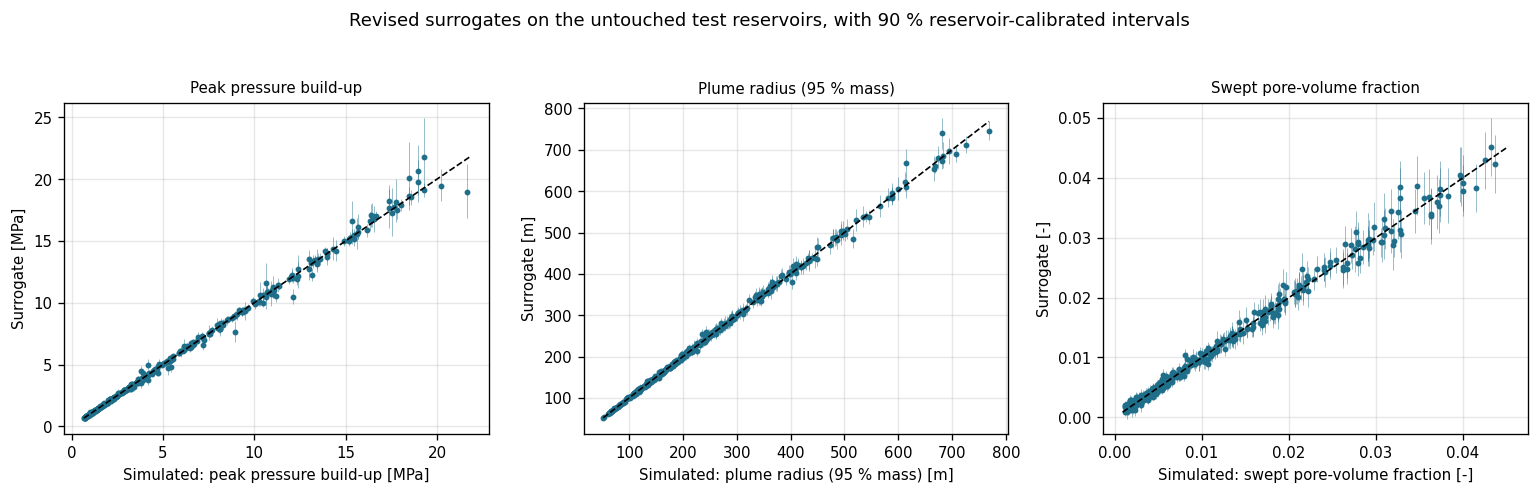

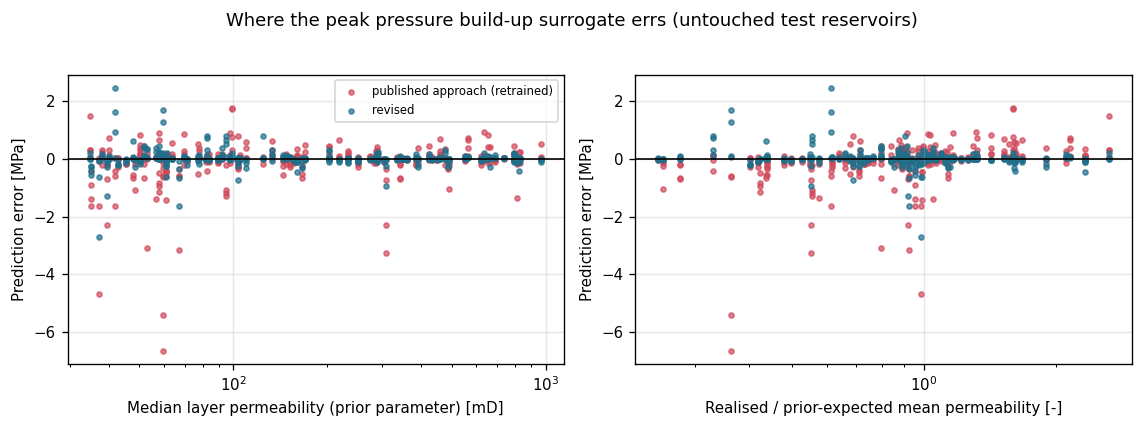

RMSE [MPa]  \
design                                                     published_approach   
grouping                       subgroup                n                        
distance to the 9 MPa limit    far from limit          353              0.704   
                               within 20% of limit     47               0.676   
median permeability tercile    high k                  152              0.418   
                               low k                   144              1.031   
                               mid k                   104              0.404   
realised vs prior permeability realised k < 0.5x prior 52               1.251   
                               realised k > 2x prior   20               0.436   
                               within 0.5-2x           328              0.583   

                                                                    \
design                                                     revised   
grouping                       subgroup                n             
distance to the 9 MPa limit    far from limit          353   0.307   
                               within 20% of limit     47    0.295   
median permeability tercile    high k                  152   0.118   
                               low k                   144   0.467   
                               mid k                   104   0.192   
realised vs prior permeability realised k < 0.5x prior 52    0.350   
                               realised k > 2x prior   20    0.128   
                               within 0.5-2x           328   0.306   

                                                           worst under-prediction [MPa]  \
design                                                               published_approach   
grouping                       subgroup                n                                  
distance to the 9 MPa limit    far from limit          353                        6.652   
                               within 20% of limit     47                         2.306   
median permeability tercile    high k                  152                        3.272   
                               low k                   144                        6.652   
                               mid k                   104                        1.275   
realised vs prior permeability realised k < 0.5x prior 52                         6.652   
                               realised k > 2x prior   20                         0.137   
                               within 0.5-2x           328                        4.678   

                                                                    
design                                                     revised  
grouping                       subgroup                n            
distance to the 9 MPa limit    far from limit          353   2.701  
                               within 20% of limit     47    1.296  
median permeability tercile    high k                  152   0.949  
                               low k                   144   2.701  
                               mid k                   104   0.717  
realised vs prior permeability realised k < 0.5x prior 52    0.228  
                               realised k > 2x prior   20    0.448  
                               within 0.5-2x           328   2.701

[LOADED from the completed study run]  subgroup errors on the test reservoirs


In [13]:
display(Image(str(Path(cfg.paths.figures)/'06_surrogate_parity.png')))
display(Image(str(Path(cfg.paths.figures)/'08_errors_dp_bh_max_MPa.png')))
sg = S['ml']['targets']['dp_bh_max_MPa']['designs']
names = {'k_group': 'median permeability tercile',
         'mismatch_group': 'realised vs prior permeability',
         'near_limit': 'distance to the 9 MPa limit'}
rows = [{'grouping': names.get(g, g), 'subgroup': lv, 'n': m['n'], 'design': d,
         'RMSE [MPa]': m['RMSE'], 'worst under-prediction [MPa]': m['worst_underprediction']}
        for d in ('revised', 'published_approach')
        for g, grp in sg[d]['evaluation']['test']['subgroups'].items()
        for lv, m in grp.items()]
display(pd.DataFrame(rows).pivot_table(index=['grouping', 'subgroup', 'n'], columns='design',
        values=['RMSE [MPa]', 'worst under-prediction [MPa]']).round(3))
provenance('loaded', 'subgroup errors on the test reservoirs')

## 8. Intervals: what they cover and what they do not

The interval method was chosen on development data by a pre-declared rule. *Case coverage* is the share of cases inside their interval; *whole-reservoir coverage* is the share of reservoirs with every schedule inside -- the property the screening relies on. All coverages here are **measured** on the independent sets. The calibration reservoirs took part in the development experiments that chose the design, so these intervals carry no finite-sample guarantee; a recalibration on fresh reservoirs follows below.

case coverage  reservoirs fully covered  \
set   method                                                         
test  empirical                    0.872                     0.770   
      case_conformal               0.880                     0.780   
      reservoir_conformal          0.920                     0.850   
      adaptive_conformal           0.950                     0.860   
shift empirical                    0.546                     0.333   
      case_conformal               0.567                     0.350   
      reservoir_conformal          0.625                     0.467   
      adaptive_conformal           0.796                     0.700   

                           mean width [MPa]  missed exceedances (upper edge)  \
set   method                                                                   
test  empirical                       0.396                                0   
      case_conformal                  0.422                                0   
      reservoir_conformal             0.562                                0   
      adaptive_conformal              0.552                                0   
shift empirical                       0.378                                5   
      case_conformal                  0.403                                5   
      reservoir_conformal             0.536                                5   
      adaptive_conformal              1.154                                2   

                           exceedances  
set   method                            
test  empirical                     90  
      case_conformal                90  
      reservoir_conformal           90  
      adaptive_conformal            90  
shift empirical                     51  
      case_conformal                51  
      reservoir_conformal           51  
      adaptive_conformal            51

domain check flags 100 % of shift reservoirs and 4 % of test reservoirs


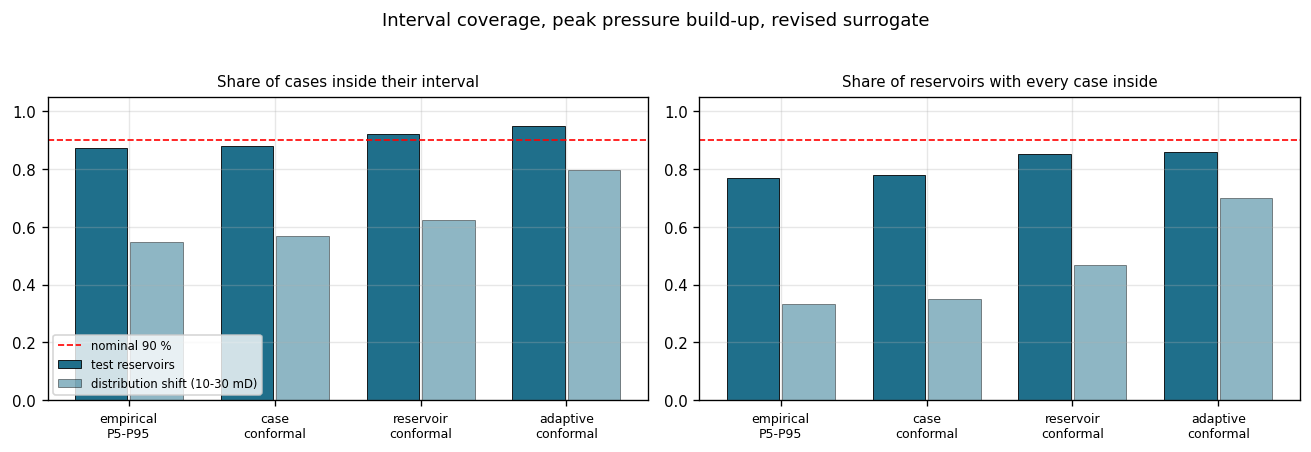

[LOADED from the completed study run]  interval evaluation, peak build-up, revised design


In [14]:
ev = S['ml']['targets']['dp_bh_max_MPa']['designs']['revised']['evaluation']
rows = []
for s_ in ('test', 'shift'):
    for meth, v in ev[s_]['intervals'].items():
        rows.append({'set': s_, 'method': meth, 'case coverage': v['case_coverage'],
                     'reservoirs fully covered': v['reservoir_all_covered'],
                     'mean width [MPa]': v['mean_width'],
                     'missed exceedances (upper edge)': v['limit_upper']['missed_exceedances'],
                     'exceedances': v['limit_upper']['n_exceeding']})
display(pd.DataFrame(rows).set_index(['set', 'method']).round(3))
print('domain check flags', round(100*ev['shift']['domain']['share_reservoirs_flagged']),
      '% of shift reservoirs and', round(100*ev['test']['domain']['share_reservoirs_flagged']),
      '% of test reservoirs')
display(Image(str(Path(cfg.paths.figures)/'18_interval_coverage.png')))
provenance('loaded', 'interval evaluation, peak build-up, revised design')

**Calibration independence (protocol addendum).** Fixed before the data existed: 41 fresh reservoirs from the development prior re-calibrate the saved design; nothing is refitted or re-selected. Only for this version does the conformal argument apply: for reservoirs drawn like the calibration reservoirs, all four schedules are covered with probability at least 0.90 on average over calibration draws. The pipeline and `subsurfaceml predict` keep the original calibration.

In [15]:
CC = json.loads((EXP/'calibration_check.json').read_text())
rows = []
for t, r in CC['targets'].items():
    m_ = r['selected_method']
    for lab, d_ in (('original (41 development reservoirs)', r['original']),
                    ('fresh (41 independent reservoirs)', r['fresh'][m_])):
        rows.append({'target': t, 'calibration': lab,
                     'test cases covered': d_['final_test']['case_coverage'],
                     'test reservoirs covered': d_['final_test']['reservoir_all_covered'],
                     'test mean width': d_['final_test']['mean_width'],
                     'shift reservoirs covered': d_['shift']['reservoir_all_covered']})
display(pd.DataFrame(rows).set_index(['target', 'calibration']).round(3))
print('original numbers reproduced from the saved models:',
      all(r['original'][s_]['matches_pipeline_record'] for r in CC['targets'].values()
          for s_ in ('final_test', 'shift')))
provenance('loaded', 'results/study/experiments/calibration_check.json')

test cases covered  \
target           calibration                                                
dp_bh_max_MPa    original (41 development reservoirs)               0.950   
                 fresh (41 independent reservoirs)                  0.970   
r_plume_m95_m    original (41 development reservoirs)               0.980   
                 fresh (41 independent reservoirs)                  0.942   
sweep_efficiency original (41 development reservoirs)               0.922   
                 fresh (41 independent reservoirs)                  0.948   

                                                       test reservoirs covered  \
target           calibration                                                     
dp_bh_max_MPa    original (41 development reservoirs)                     0.86   
                 fresh (41 independent reservoirs)                        0.91   
r_plume_m95_m    original (41 development reservoirs)                     0.97   
                 fresh (41 independent reservoirs)                        0.88   
sweep_efficiency original (41 development reservoirs)                     0.78   
                 fresh (41 independent reservoirs)                        0.84   

                                                       test mean width  \
target           calibration                                             
dp_bh_max_MPa    original (41 development reservoirs)            0.552   
                 fresh (41 independent reservoirs)               0.715   
r_plume_m95_m    original (41 development reservoirs)           20.782   
                 fresh (41 independent reservoirs)              16.418   
sweep_efficiency original (41 development reservoirs)            0.003   
                 fresh (41 independent reservoirs)               0.003   

                                                       shift reservoirs covered  
target           calibration                                                     
dp_bh_max_MPa    original (41 development reservoirs)                     0.700  
                 fresh (41 independent reservoirs)                        0.733  
r_plume_m95_m    original (41 development reservoirs)                     0.783  
                 fresh (41 independent reservoirs)                        0.633  
sweep_efficiency original (41 development reservoirs)                     0.800  
                 fresh (41 independent reservoirs)                        0.817

original numbers reproduced from the saved models: True
[LOADED from the completed study run]  results/study/experiments/calibration_check.json


## 9. Verification-gated schedule screening

No schedule is recommended unless the simulator has run it and it met both stated limits. Five methods share a budget of four simulations per reservoir (three for the published method, as published); the baseline every gain is measured against is a simulator-only constant-rate search.

reservoirs  verified  no feasible found  \
set        method                                                         
final_test rom_constant                 20        20                  0   
           rom_shaped                   20        20                  0   
           simulator_constant           20        20                  0   
           surrogate_published          20        19                  1   
           surrogate_verified           20        20                  0   
shift      rom_constant                 10        10                  0   
           rom_shaped                   10        10                  0   
           simulator_constant           10        10                  0   
           surrogate_published          10         9                  1   
           surrogate_verified           10        10                  0   

                                first simulated proposal violated  \
set        method                                                   
final_test rom_constant                                        13   
           rom_shaped                                           5   
           simulator_constant                                   0   
           surrogate_published                                  1   
           surrogate_verified                                   0   
shift      rom_constant                                         4   
           rom_shaped                                           2   
           simulator_constant                                   0   
           surrogate_published                                  2   
           surrogate_verified                                   4   

                                median mass vs constant [%]  mean simulations  
set        method                                                              
final_test rom_constant                                0.07              2.65  
           rom_shaped                                  3.42              2.70  
           simulator_constant                          0.00              3.40  
           surrogate_published                        -9.56              3.00  
           surrogate_verified                          2.88              3.25  
shift      rom_constant                                0.02              2.50  
           rom_shaped                                 11.12              2.40  
           simulator_constant                          0.00              3.20  
           surrogate_published                       -11.84              3.00  
           surrogate_verified                          0.02              2.50

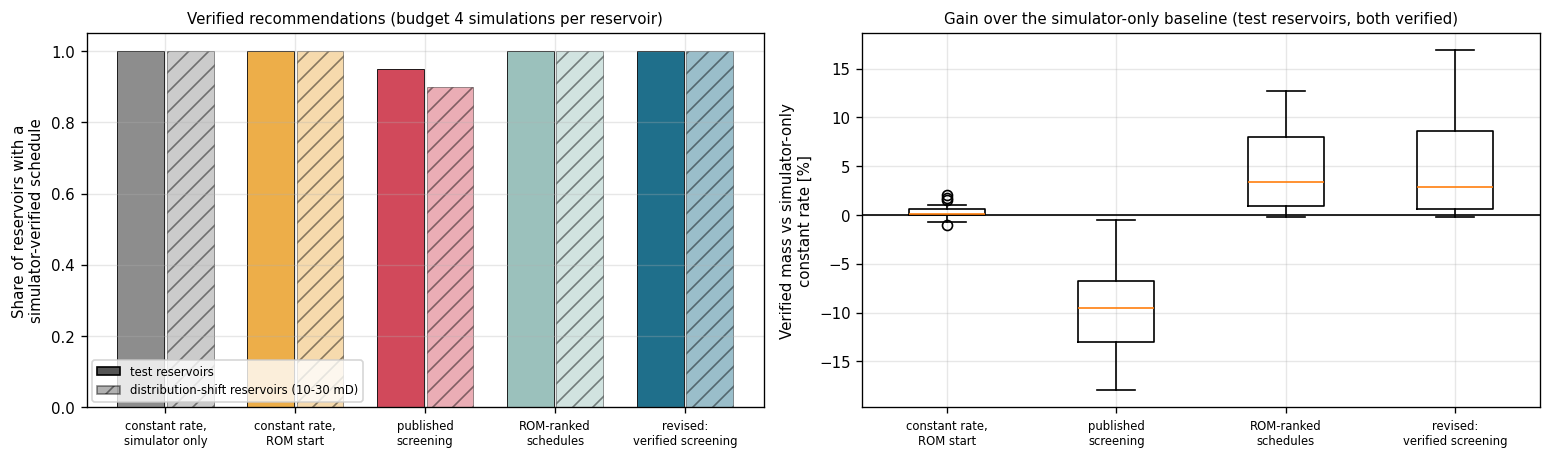

[LOADED from the completed study run]  results/study/metrics/screening_recommendations.csv


In [16]:
SC = S['screening']
rows = []
for s_, d in SC['by_set'].items():
    for meth, v in d['methods'].items():
        rows.append({'set': s_, 'method': meth, 'reservoirs': d['n_reservoirs'],
                     'verified': v['n_verified'], 'no feasible found': v['n_no_feasible_found'],
                     'first simulated proposal violated': v['first_simulated_schedule_violates'],
                     'median mass vs constant [%]': v['median_mass_vs_constant_pct'],
                     'mean simulations': v['mean_simulations']})
display(pd.DataFrame(rows).set_index(['set', 'method']).round(2))
display(Image(str(Path(cfg.paths.figures)/'15_schedule_screening.png')))
provenance('loaded', 'results/study/metrics/screening_recommendations.csv')

## 10. Conclusions and limitations

**What the study shows** (numbers in the cells above, from the completed study run)

* The simulator passes 21 verification checks, including its two-phase bottom-hole pressure against the pseudo-steady-state solution, and the discretisation error of the training targets is small for pressure (section 3).
* The published surrogate's largest pressure errors had one cause: it described each reservoir by the parameters of its sampling prior rather than by the realised layers the simulator used (section 5). More model capacity did not help; correcting the inputs and learning only the correction to an analytical ROM did (section 6).
* On reservoirs generated after every choice was fixed, the hybrid surrogate roughly halves the peak-pressure RMSE of the published approach trained on the same data, lowers its worst under-prediction, and misses no exceedance of the assumed limit (section 7).
* Intervals calibrated by reservoir are about three times narrower than the published band at similar measured whole-reservoir coverage (86 % of test reservoirs; 91 % after recalibration on fresh reservoirs); pooled calibration under-covers whole reservoirs, and no interval keeps its coverage under the distribution shift (section 8).
* Every recommended schedule is verified by the simulator -- against the assumed limits, within the layered model's assumptions. Shaped schedules gain a few per cent over the best constant rate; the analytical ROM ranks schedules as well as the learned surrogate, whose value is in accurate predictions and safe first proposals (section 9).

**Limitations, stated plainly**

* All data are synthetic; there is no field data and no field validation.
* The data-generating model has no gravity or crossflow; adding them changes the peak build-up by a few per cent but the plume radius by a factor of about two, so plume results describe the layered model only (section 3).
* The 9 MPa build-up limit and the 400 m plume limit are modelling assumptions, not validated fracture-pressure or caprock criteria.
* The pipeline's intervals have measured coverage only; after recalibration on fresh reservoirs, interval statements apply to reservoirs drawn like the calibration ones. The domain check flags reservoirs outside the training population, and the screening then falls back to the simulator.
* The most extreme build-up case remains under-predicted by about 15 %.

**Where to look next**

| Question | File |
|---|---|
| What was decided before the test data existed? | `docs/EVALUATION_PROTOCOL.md` |
| Full method and results | `docs/TECHNICAL_REPORT.md` |
| Which source is each component from? | `docs/SOURCE_MAP.md` |
| What exactly was assumed? | `docs/ASSUMPTIONS.md` |
| Every number of the run | `results/study/reports/RESULTS.md` |
| Optional deeper analyses | `notebooks/supporting/` |